In [11]:
import numpy as np
import math
import mode_analysis_fmm_repo as ma_fmm
import mode_analysis_code_original_repo as ma_orig
import random as rand 
from scipy.stats import maxwell
import matplotlib.pyplot as plt

import sys
# Set this to the path containing the FMM3D Python package on your system.
FMM3D_PYTHON_PATH = "/path/to/FMM3D/python"
sys.path.append(FMM3D_PYTHON_PATH)
import fmm3dpy as fmm

import multiprocessing

Here we initialize a 3D crystal. For further explanations of the following cells, see file 'initialize_crystal'.

In [12]:
#ion parameters
num_ions=100                #number of ions in crystal 
q = 1.602176597458587e-19  #ion charge in C
mass_amu=9.012182          #ion mass in amu
T_axial = 0.01            #initial temperature of axial modes (K)
T_perp = 0.0             #initial temperature of planar modes (K)

#trap parameters
Bz =4.4588                   #magnetic field in T
wz = 2*np.pi*1.59e6          #axial trapping frequency in rad/sec
wr=240000*2*np.pi            #rotating wall frequency in rad/sec
delta=0.035                  #relative strength of rotating wall potential

#laser beam and transition parameters
c = 3*10**8                    #speed of light m/s
w_e_g1 = 957*10**12*2*np.pi    #transition freq. between states |e> and |g1> rad/sec
w_g2_g1 = 124*10**9*2*np.pi    #transition freq. between states |g2> and |g1> rad/sec
beam_ang = 10                  #angle which beam k-vector makes with x-y plane degrees
                                  #(angle between beams is then 2*beam_ang)
rabi1_eit = 33.909530*10**6*2*np.pi    #Rabi frequency of EIT beam 1 rad/sec
rabi2_eit = 33.909530*10**6*2*np.pi    #EIT beam 2
det1_eit = 360.0*10**6*2*np.pi         #Detuning of EIT beam from resonance rad/sec
det2_eit = 360.0*10**6*2*np.pi         #EIT beam 2
gamma1_eit = 6.0*10**6*2*np.pi         #Spontaneous decay rate |e> --> |g1> rad/sec
gamma2_eit = 12.0*10**6*2*np.pi        #|e> --> |g2>
beam_w_eit = -1.0                              #beam waist in meters (-1.0 is infinite waist)
dens_mat = np.array([[1.0,0.0,0.0], [0.0,0.0,0.0], [0.0,0.0,0.0]])    #initial ion internal-state density matrix

#time parameters
dt = 1.0e-10         #timestep in sec
duration = 1.0e-3    #total sim. duration
steps = 1.0e7        #number of steps
write_per = 100000    #write to output file every write_per steps

input_name = 'EIT_100i_3D_092926'  #name of input file to be created

In [13]:
#Additional definitions (do not change these definitions.  Instead, change the parameter values in the cell above)

m = mass_amu*1.66057e-27   #ion mass in kg

wc = q*Bz/m                #cyclotron frequency
frot = wr/(2*np.pi)        #rotating wall freq in Hz
frot_kHz = frot/(1000)     #rotatring wall freq in kHz
Vw = 0.5*(m*wz**2/q)*delta   #rotating wall strength
v_wall= delta*0.5*m*wz**2 / (1612.*q) #rotating wall strength in code units
kz = m*wz**2 /q            #axial trapping strength
phi0 = np.pi/2             #initial phase of rotaintg wall potential (do not change)

k1x_eit = (w_e_g1+det1_eit)*np.cos(beam_ang*np.pi/180)/c           #k-vector beam 1
k1y_eit = 0.0
k1z_eit = (w_e_g1+det1_eit)*np.sin(beam_ang*np.pi/180)/c
k1_eit = np.array([k1x_eit,k1y_eit,k1z_eit])             
k2x_eit = (w_e_g1-w_g2_g1+det2_eit)*np.cos(beam_ang*np.pi/180)/c   #k-vector beam 1
k2y_eit = 0.0
k2z_eit = -1*(w_e_g1-w_g2_g1+det2_eit)*np.sin(beam_ang*np.pi/180)/c
k2_eit = np.array([k2x_eit,k2y_eit,k2z_eit])

#constants
eps0 = 8.85418782*10**-12
kboltz = 1.380649*10**-23
k_e = 8.9875517873681764E9

In [14]:
method='bfgs' 

#initialize mode analysis
ma_instance=ma_fmm.ModeAnalysis(
            N      = num_ions,
            ionmass= mass_amu,
            omega_z = wz,
            Vwall  = v_wall,
            B=Bz,
            frot   = frot_kHz,
            method = method)

#initialize seed configuration with random positions in a sphere
rad = 2*10**-4 #test
vol = 4/3*np.pi*rad**3
rand_pos_x = np.empty(num_ions)
rand_pos_y = np.empty(num_ions)
rand_pos_z = np.empty(num_ions)
for i in range(num_ions):
    this_vol = rand.random()*vol
    this_rad = (3/(4*np.pi)*this_vol)**(1/3)
    #this_theta = rand.random()*np.pi
    qq = rand.random()
    this_theta = np.arccos(2.*qq-1.)
    this_phi = rand.random()*2*np.pi
    rand_pos_x[i] = this_rad * np.sin(this_theta) * np.cos(this_phi)
    rand_pos_y[i] = this_rad * np.sin(this_theta) * np.sin(this_phi)
    rand_pos_z[i] = this_rad * np.cos(this_theta)

rand_pos = np.concatenate((rand_pos_x,rand_pos_y, rand_pos_z), axis = None)

#compute 3D equilibrium and normal modes
ma_instance.run3D(rand_pos)
pos = ma_instance.uE

pos_2D = np.array([pos[:num_ions],pos[num_ions:2*num_ions],pos[2*num_ions:]])

eq_pos_x = pos_2D[0].copy()
eq_pos_y = pos_2D[1].copy()
eq_pos_z = pos_2D[2].copy()

False
Desired error not necessarily achieved due to precision loss.
first minimization: 1508.1064344496995


Plotting the equilibrium configuraiton,

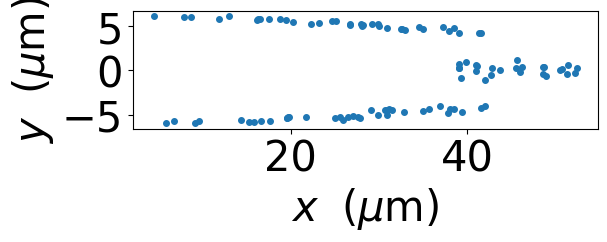

In [15]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot()
ax = fig.axes[0]
ax.plot(np.sqrt(eq_pos_x**2+eq_pos_y**2)*10**6, eq_pos_z*10**6, linestyle = " ", marker = '.', markersize=8)
ax.set_aspect('equal')
ax.set_xlabel(r'$x\;$ ($\mu$m)', fontsize=30)
ax.set_ylabel(r'$y\;$ ($\mu$m)', fontsize=30)
ax.tick_params(axis='both', labelsize=30)

Saving the crystal's equilibrium configuration, eigenvectors, eigenvalues, and energy matrices

In [16]:
np.save("normal_modes/eq_pos_" + str(input_name) + ".npy", pos_2D)
np.save("normal_modes/3D_evects_" + str(input_name) + ".npy", ma_instance.Evects3D)
np.save("normal_modes/3D_evals_" + str(input_name) + ".npy", ma_instance.Evals3D)

####### 3D energy matrix ############

l0 = (k_e * q ** 2 / (.5 * m * wz ** 2)) ** (1 / 3)

V = -ma_instance.hessian_penning_3D(pos_2D.flatten()/l0)  # -Hessian
Z3n = np.zeros((3 * num_ions, 3 * num_ions))
#Mmat = np.diag(m)/m[0]
Mmat3 = np.eye(3*num_ions)
En_mat = np.bmat([[-V/2, Z3n], [Z3n, Mmat3]])  

np.save("normal_modes/3D_energy_matrix_" + str(input_name) + ".npy", En_mat)

We define the axial modes in a 3D crystal as the $N$ modes with the largest axial component.  In oblate 3D crystals, these are generally the $N$ middle-frequency modes, but this is not always the case in prolate crystals, where ExB modes can often have higher frequencies than axial modes.  In the following cell, we compute the axial fraction of each mode and find the $N$ modes with the largest axial fraction.

In [17]:
## Compute axial fraction of each mode
axial_fraction = np.zeros(3*num_ions)

for j in range(3*num_ions):

    ev = np.asarray(ma_instance.Evects3D[:, 2*j]).ravel()

    ex = ev[0:num_ions]
    ey = ev[num_ions:2*num_ions]
    ez = ev[2*num_ions:3*num_ions]

    axial_fraction[j] = (
        np.sum(np.abs(ez)**2)
        /
        (
            np.sum(np.abs(ex)**2)
            + np.sum(np.abs(ey)**2)
            + np.sum(np.abs(ez)**2)
        )
    )

## find indices of the axial modes
axial_mode_indices = np.sort(np.argsort(axial_fraction)[-num_ions:])

In [18]:
axial_mode_indices

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164,
       165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177,
       178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190,
       191, 192, 193, 194, 195, 196, 197, 198, 199])

Below, we initialize a sample of crystals at the given temperatures $T_{axial}$ and $T_{perp}$.  The crystals have random mode phases and the number of crystals can be specified by changing 'num_runs'.  The ExB modes are initialized using a Metropolis-hastings algorithm whose step size is specified using 'step'.

The associated simulation input files are also created.

In [19]:
num_runs = 1      #number of independent runs
step = 1*10**-6   #MH step size in meters
MC_iter = 500     #number of MH iterations


def initialize_crystal(file_index):

    rng = np.random.default_rng(file_index)

    #MH algorithm to excite ExB modes
    def simulated_annealing_2D(energy, start_pos, n_iterations, step_size, temp):
        best = start_pos.copy()  #lowest energy configuration
        position_list = np.array([[]])
        best_eval = energy(start_pos)  #evaluate the initial point
        energies = np.array([])
        curr = best.copy()
        curr_eval = best_eval
        write_per = 10  #how often to write configuration to position_list
        counter = 0
        position_list = np.array([start_pos.copy()])
        accept_inc =0
        accept_dec =0
        num_ions = np.size(start_pos[0])
        energies = np.append(energies, energy(curr))
        for i in range(n_iterations):
        # take a step
            print(i)
            for j in range(num_ions):
                add_arr = (rng.random(2)-0.5) * step_size
                curr[:2,j] += add_arr
                # evaluate candidate point
                candidate_eval = energy(curr)
                # check for new best solution
                if candidate_eval < best_eval:
                    # store new best point
                    best = curr.copy()
                    best_eval = candidate_eval
                    counter+=1
                    if counter % write_per == 0:
                        position_list = np.append(position_list, [best.copy()], axis = 0)
                # difference between candidate and current point evaluation
                diff = candidate_eval - curr_eval
                # calculate temperature for current epoch
                t=temp
                # calculate metropolis acceptance criterion
                metropolis = np.exp(-diff / (kboltz*t))
                # check if we should keep the new point
                if diff < 0 or rng.random() < metropolis:
                    # store the new current point
                    curr_eval = candidate_eval
                    energies = np.append(energies, candidate_eval)
                    counter+=1
                    if diff > 0:
                        #print("energy increase ion " + str(j))
                        accept_inc+=1
                    if diff < 0:
                        accept_dec+=1
                        #print("energy decrease ion " + str(j))
                else:
                    curr[:2,j] -= add_arr
        return [best, best_eval, position_list, curr, accept_dec, accept_inc, energies]
    
    
    
    def pot_eng_ax_pl_trap_2D(position):
        mass_amu=9.012182
        q = 1.602176597458587e-19
        m = mass_amu*1.66057e-27
        shape   = np.shape(position)
        dims,ions=shape
        x = position[0,:]
        y = position[1,:]
        z = position[2,:]
        pot_eng_ion = np.zeros(ions)
        #pot_eng_ion = np.zeros((ions,1))
        pot_eng_ion[:] += 0.5*m*wz**2*np.square(z)
        pot_eng_ion[:] += -0.5*m*(wr**2 - wr*wc + 0.5*wz**2) *(np.square(x)+np.square(y))
        pot_eng_ion[:] += q*Vw*(np.square(x)-np.square(y))
        return np.sum(pot_eng_ion)
    
    def pot_eng_coul_2D(position):
        mass_amu=9.012182
        q = 1.602176597458587e-19
        m = mass_amu*1.66057e-27
        shape   = np.shape(position)
        dims,ions=shape
        x = position[0,:]
        y = position[1,:]
        z = position[2,:]
        pot_eng_ion = np.zeros(ions)
        for ion1 in range(ions):
            for ion2 in range(ions):
                if ion1!=ion2:
                    dx = x[ion1] - x[ion2]
                    dy = y[ion1] - y[ion2]
                    dz = z[ion1] - z[ion2]
                    r = np.sqrt(dx**2 + dy**2+dz**2)
                    #r = np.sqrt(dx**2 + dy**2)
                    pot_eng_ion[ion1] += q**2/(4*np.pi*eps0*r)
        return np.sum(pot_eng_ion)/2
    
        
    def pot_en_2D(position):
        return pot_eng_ax_pl_trap_2D(position) + pot_eng_coul_2D(position)


    if(T_perp > 0.0):
        pos_MC_2D = simulated_annealing_2D(pot_en_2D, pos_2D.copy(), MC_iter,step,T_perp)
        np.savetxt("energy_init/energies_MC_" + str(input_name) + "_" +str(file_index) + ".csv", pos_MC_2D[-1], delimiter = ' ')
    
        start_pos_x = pos_MC_2D[3][0].copy()
        start_pos_y = pos_MC_2D[3][1].copy()
        start_pos_z = eq_pos_z.copy()

    else:
        eq_en = pot_en_2D(pos_2D.copy())
        np.savetxt("energy_init/energies_MC_" + str(input_name) + "_" +str(file_index) + ".csv", np.array([eq_en]), delimiter = ' ')
        start_pos_x = eq_pos_x.copy()
        start_pos_y = eq_pos_y.copy()
        start_pos_z = eq_pos_z.copy()
    
    vel_x= []
    vel_y= []
    vel_z=[]
    m = []
    q=[]
    
    for i in range(num_ions):
        vel_x.append(-wr*start_pos_y[i])
        vel_y.append(wr*start_pos_x[i])
        q.append(1.602176597458587e-19)
        m.append(mass_amu*1.66057e-27)

    ### EXCITE AXIAL MODES ###
    amp = np.sqrt(kboltz * 2*T_axial / ma_instance.E0)
    start_pos_x =np.array(start_pos_x)
    vel_x=np.array(vel_x)
    start_pos_y =np.array(start_pos_y)
    vel_y=np.array(vel_y)
    start_pos_z =np.array(start_pos_z)
    vel_z=np.zeros(num_ions)
    for mode in axial_mode_indices: 
        this_theta = 2 * np.pi * rng.random()
  
        dx = np.real((np.array(ma_instance.Evects3D[:,2*mode][0*num_ions:1*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.l0
        dvx= np.real((np.array(ma_instance.Evects3D[:,2*mode][3*num_ions:4*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.v0
        dy = np.real((np.array(ma_instance.Evects3D[:,2*mode][1*num_ions:2*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.l0
        dvy= np.real((np.array(ma_instance.Evects3D[:,2*mode][4*num_ions:5*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.v0
        dz = np.real((np.array(ma_instance.Evects3D[:,2*mode][2*num_ions:3*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.l0
        dvz= np.real((np.array(ma_instance.Evects3D[:,2*mode][5*num_ions:6*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.v0
        
        start_pos_x = start_pos_x + dx
        vel_x = vel_x + dvx
        start_pos_y = start_pos_y + dy
        vel_y = vel_y + dvy
        start_pos_z = start_pos_z + dz
        vel_z = vel_z + dvz

    ### EXCITE CYCLOTRON MODES ###
    amp = np.sqrt(kboltz * 2*T_perp / ma_instance.E0)
    for mode in range(num_ions): 
        this_theta = 2 * np.pi * rng.random()

        dx = np.real((np.array(ma_instance.Evects3D[:,4*num_ions+2*mode][0*num_ions:1*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.l0
        dvx= np.real((np.array(ma_instance.Evects3D[:,4*num_ions+2*mode][3*num_ions:4*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.v0
        dy = np.real((np.array(ma_instance.Evects3D[:,4*num_ions+2*mode][1*num_ions:2*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.l0
        dvy= np.real((np.array(ma_instance.Evects3D[:,4*num_ions+2*mode][4*num_ions:5*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.v0
        dz = np.real((np.array(ma_instance.Evects3D[:,4*num_ions+2*mode][2*num_ions:3*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.l0
        dvz= np.real((np.array(ma_instance.Evects3D[:,4*num_ions+2*mode][5*num_ions:6*num_ions]*np.exp(1j*this_theta)).T)[0])*amp*ma_instance.v0

        start_pos_x = start_pos_x + dx
        vel_x = vel_x + dvx
        start_pos_y = start_pos_y + dy
        vel_y = vel_y + dvy
        start_pos_z = start_pos_z + dz
        vel_z = vel_z + dvz


    gamma_0_trans = 0.0 #unused variable from deprecated code
    num_beams=0 #unused variable
    
    
    f = open("input/input_" + str(input_name) + "_" + str(file_index) + '.txt', 'w')
    
    for i in range(len(start_pos_x)):
        if(i < len(start_pos_x)-1):
            f.write("{:e}".format(start_pos_x[i]) + " ")
        else:
            f.write("{:e}".format(start_pos_x[i]))
    f.write("\n")
    
    for i in range(len(start_pos_y)):
        if(i < len(start_pos_y)-1):
            f.write("{:e}".format(start_pos_y[i]) + " ")
        else:
            f.write("{:e}".format(start_pos_y[i]))
    f.write("\n")
    
    for i in range(len(start_pos_z)):
        if(i < len(start_pos_z)-1):
            f.write("{:e}".format(start_pos_z[i]) + " ")
        else:
            f.write("{:e}".format(start_pos_z[i]))
    f.write("\n")
    
    for i in range(len(vel_x)):
        if(i < len(vel_x)-1):
            f.write("{:e}".format(vel_x[i]) + " ")
        else:
            f.write("{:e}".format(vel_x[i]))
    f.write("\n")
    
    for i in range(len(vel_y)):
        if(i < len(vel_y)-1):
            f.write("{:e}".format(vel_y[i]) + " ")
        else:
            f.write("{:e}".format(vel_y[i]))
    f.write("\n")
    
    for i in range(len(vel_z)):
        if(i < len(vel_z)-1):
            f.write("{:e}".format(vel_z[i]) + " ")
        else:
            f.write("{:e}".format(vel_z[i]))
    f.write("\n")
    
    for i in range(len(q)):
        if(i < len(q)-1):
            f.write("{:.10e}".format(q[i]) + " ")
        else:
            f.write("{:.10e}".format(q[i]))
    f.write("\n")
    
    for i in range(len(m)):
        if(i < len(m)-1):
            f.write("{:.10e}".format(m[i]) + " ")
        else:
            f.write("{:.10e}".format(m[i]))
    f.write("\n")
    
    f.write("{:e}".format(dt) + "\n")
    
    f.write("{:e}".format(duration) + "\n")
    
    f.write("{:e}".format(steps) + "\n")
    
    f.write("{:e}".format(write_per) + "\n")
    
    f.write("{:.10e}".format(Bz) + "\n")
    
    f.write("{:.10e}".format(kz) + "\n")
    
    f.write("{:.10e}".format(delta) + "\n")
    
    f.write("{:.10e}".format(wr) + "\n")
    
    f.write("{:.10e}".format(phi0) + "\n")
    
    f.write("{:e}".format(gamma_0_trans))
    f.write("\n")
    
    for i in range(num_beams):
        if(i < num_beams-1):
            f.write("{:.10e}".format(beam_S0[i]) + " ")
        else:
            f.write("{:.10e}".format(beam_S0[i]) + " ")
    f.write("\n")
    
    for i in range(3):
        for j in range(num_beams):
            if(j < num_beams-1):
                f.write("{:e}".format(beam_k[j][i]) + " ")
            else:
                f.write("{:e}".format(beam_k[j][i]))
        f.write("\n")
    
    for i in range(3):
        for j in range(num_beams):
            if(j < num_beams-1):
                f.write("{:e}".format(beam_waist[j][i]) + " ")
            else:
                f.write("{:e}".format(beam_waist[j][i]))
        f.write("\n")

    
    for i in range(3):
        for j in range(num_beams):
            if(j < num_beams-1):
                f.write("{:e}".format(beam_disp[j][i]) + " ")
            else:
                f.write("{:e}".format(beam_disp[j][i]))
        f.write("\n")
    
    
    for i in range(num_beams):
        if(i < num_beams-1):
            f.write("{:e}".format(beam_det[i]) + " ")
        else:
            f.write("{:e}".format(beam_det[i]))
    f.write("\n")

    #EIT params
    f.write("{:.10e}".format(rabi1_eit) + "\n")
    f.write("{:.10e}".format(rabi2_eit) + "\n")
    f.write("{:.10e}".format(det1_eit) + "\n")
    f.write("{:.10e}".format(det2_eit) + "\n")
    f.write("{:.10e}".format(gamma1_eit) + "\n")
    f.write("{:.10e}".format(gamma2_eit) + "\n")
    f.write("{:.10e}".format(k1x_eit) + " " + "{:.10e}".format(k1y_eit) + " " + "{:.10e}".format(k1z_eit) + "\n")
    f.write("{:.10e}".format(k2x_eit) + " " + "{:.10e}".format(k2y_eit) + " " + "{:.10e}".format(k2z_eit) + "\n")
    f.write("{:.10e}".format(beam_w_eit) + "\n")
    for i in range(3):
        for j in range(3):
            if(i<2 or j<2):
                f.write("{:.10e}".format(dens_mat[i,j]) + " ")
            else:
                f.write("{:.10e}".format(dens_mat[i,j]))
    f.write("\n")
    

    f.close()
    

params = []
for i in range(num_runs):
    params.append([i])

with multiprocessing.Pool(processes=20) as pool:
    results=pool.starmap(initialize_crystal, params)

We can plot the potential energy during the Metropolis-Hastings initialization to verify that it works successfully.

In [12]:
import matplotlib.pyplot as plt


energy_mc = np.loadtxt("energy_init/energies_MC_EIT_100i_3D_092926_0.csv", delimiter = ' ')
emin = energy_mc[0]
plt.plot(np.linspace(0,energy_mc.size,energy_mc.size), energy_mc)
#initial (equilibrium) energy:
plt.plot(np.linspace(0,energy_mc.size,energy_mc.size), np.full(energy_mc.size,emin)) 
#energy corresponding to 10 mK (three spatial dimensions)
plt.plot(np.linspace(0,energy_mc.size,energy_mc.size), np.full(energy_mc.size,emin+(num_ions*1.0*kboltz*0.01)))  

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

NameError: name 'energy_mc' is not defined